In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from search.parallel_gradient import ParallelGradientDescent
from utils.sampling import BatchNegativeSampler

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[KeOps] Warning : CUDA libraries not found or could not be loaded; Switching to CPU only.


In [2]:
#look for experiment files in parents
import os
path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)


In [3]:
experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")

In [4]:
dataset ="mnist"
architecture = "resnet_small"
budget = 120

In [5]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)
#dataset_info.transform_seq_name = "mnist_reflection"
dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data)


C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\torch_geometric\typing.py:68: UserWarning: An issue occurred while importing 'pyg-lib'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\Lib\site-packages\libpyg.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'pyg-lib'. "
C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\lib\site-packages\torch_geometric\typing.py:97: UserWarning: An issue occurred while importing 'torch-cluster'. Disabling its usage. Stacktrace: Could not find module 'C:\Users\Lindner\PycharmProjects\experiments_rotation\.venv\Lib\site-packages\torch_cluster\_grid_cuda.pyd' (or one of its dependencies). Try using the full path with constructor syntax.
  warnings.warn(f"An issue occurred while importing 'torch-cluster'. "
C:\Users\Lindner\PycharmProjects\experiments_rotation\.ven

In [6]:
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']



In [7]:
from utils.transforms.apply import (
    grid_resample,
    grid_resample_nearest,
    grid_resample_bicubic,
    grid_resample_deblur,
)

resample_methods = {
    "nearest": grid_resample_nearest,
    "bicubic": grid_resample_bicubic,
    "deblur": grid_resample_deblur,
}

transformed_loaders = {}

for name, method in resample_methods.items():
    info = get_dataset_info(dataset)
    info.transform_seq_name = "mnist_reflection"
    info.sample_method = method
    info.resample_method = method
    dset_dict = get_dataset(info, path=experiment_files_path_data)
    transformed_loaders[name] = dset_dict["test_loader_transformed"]

# Example: Access the transformed loader for 'nearest'
train_loader_transformed_nearest = transformed_loaders["nearest"]
train_loader_transformed_bicubic = transformed_loaders["bicubic"]
train_loader_transformed_deblur = transformed_loaders["deblur"]

val_loader_transformed_nearest = transformed_loaders["nearest"]
val_loader_transformed_bicubic = transformed_loaders["bicubic"]
val_loader_transformed_deblur = transformed_loaders["deblur"]

test_loader_transformed_nearest = transformed_loaders["nearest"]
test_loader_transformed_bicubic = transformed_loaders["bicubic"]
test_loader_transformed_deblur = transformed_loaders["deblur"]


In [8]:
batch_size = next(iter(train_loader))[0].shape[0]

Text(0.5, 1.0, 'Test')

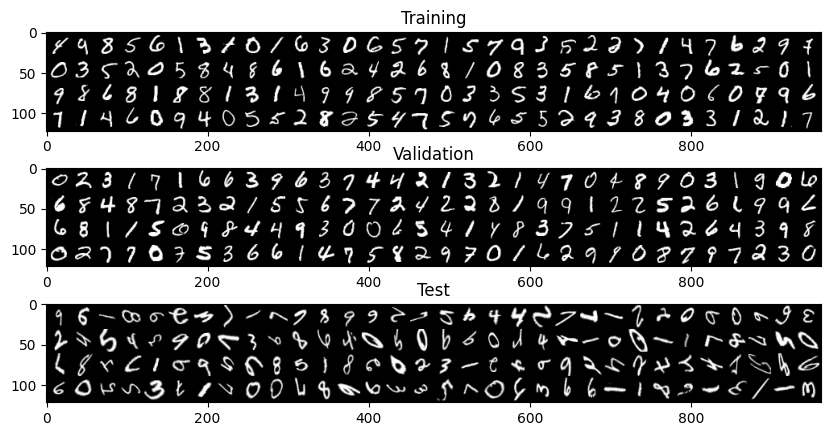

In [9]:
#test images
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(10, 5))

axs[0].imshow(torchvision.utils.make_grid(next(iter(train_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[1].imshow(torchvision.utils.make_grid(next(iter(val_loader))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[2].imshow(torchvision.utils.make_grid(next(iter(test_loader_transformed))[0], nrow=batch_size//4).permute(1, 2, 0).cpu())
axs[0].set_title('Training')
axs[1].set_title('Validation')
axs[2].set_title('Test')



In [10]:
test_loader_transformed.dataset.transformation_matrices.det().min()

tensor(0.5957)

In [11]:
from experiment_thesis.main import train_and_get_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")

model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": 100,
        "precision": "16-mixed",
},load_if_exists=True)


res = evaluate_base_model(model, test_loader_transformed, device)
print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\mnist_resnet_small.safetensors


{'accuracy': 0.4413999915122986, 'f2_macro': 0.43061476945877075, 'f2_micro': 0.4413999915122986, 'f2_weighted': 0.43389666080474854}


In [12]:
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images
if dataset_info.transform_seq_name is not None and dataset_info.datatype == "image":
    transform_seq = get_transformation_sequence_images(
                name=dataset_info.transform_seq_name,
                resample_method=dataset_info.resample_method
    ).cuda()

In [13]:
model

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [14]:
from torchinfo import summary
summary(model, (1,1, 28, 28))

Layer (type:depth-idx)                        Output Shape              Param #
FlexibleResNet                                [1, 10]                   --
├─Conv2d: 1-1                                 [1, 64, 28, 28]           576
├─BatchNorm2d: 1-2                            [1, 64, 28, 28]           128
├─GELU: 1-3                                   [1, 64, 28, 28]           --
├─ModuleList: 1-4                             --                        --
│    └─Sequential: 2-1                        [1, 64, 28, 28]           --
│    │    └─BasicBlock: 3-1                   [1, 64, 28, 28]           73,984
│    └─Sequential: 2-2                        [1, 128, 14, 14]          --
│    │    └─BasicBlock: 3-2                   [1, 128, 14, 14]          230,144
│    └─Sequential: 2-3                        [1, 256, 7, 7]            --
│    │    └─BasicBlock: 3-3                   [1, 256, 7, 7]            919,040
│    └─Sequential: 2-4                        [1, 512, 4, 4]            --
│   

In [15]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache

transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

layer = "head_pool"
mode = "input"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=mode, flatten=False)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=mode, concat=False, flatten=False)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((2, 2), None)
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512, method="orthogonal")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=input_transform_pca)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")

random_search = shgo.SHGO(initial_samples=120*1, local_runs=1, local_max_steps=0, project_param=False)
model.cuda().eval()
evaluate_confidence_and_search(model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
                               test_loader=test_loader_transformed,
                               max_batch_override=1280)


{'repeats': 1,
 'accuracy_mean': 0.9401999711990356,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9378504157066345,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9401999711990356,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.940202534198761,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9401999711990356,
   'f2_macro': 0.9378504157066345,
   'f2_micro': 0.9401999711990356,
   'f2_weighted': 0.940202534198761}]}

In [16]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache

transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

layer = "stages.1.0.act"
mode = "input"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=mode, flatten=False)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=mode, concat=False, flatten=False)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((2, 2), None)
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512, method="orthogonal")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=input_transform_pca)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")

random_search = shgo.SHGO(initial_samples=120*1, local_runs=1, local_max_steps=0, project_param=False)
model.cuda().eval()
evaluate_confidence_and_search(model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
                               test_loader=test_loader_transformed,
                               max_batch_override=1280)


{'repeats': 1,
 'accuracy_mean': 0.9426000118255615,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.940979540348053,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9426000118255615,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9424850344657898,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9426000118255615,
   'f2_macro': 0.940979540348053,
   'f2_micro': 0.9426000118255615,
   'f2_weighted': 0.9424850344657898}]}

In [17]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache

transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

layer = "stages.2.0.act"
mode = "input"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=mode, flatten=False)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=mode, concat=False, flatten=False)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((2, 2), None)
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(1024, method="sparse",sparsity=30)

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=input_transform_random)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")

random_search = shgo.SHGO(initial_samples=120*1, local_runs=1, local_max_steps=0, project_param=False)
model.cuda().eval()
evaluate_confidence_and_search(model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
                               test_loader=test_loader_transformed,
                               max_batch_override=1280)


{'repeats': 1,
 'accuracy_mean': 0.9595999717712402,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9586122035980225,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9595999717712402,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.9595820903778076,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9595999717712402,
   'f2_macro': 0.9586122035980225,
   'f2_micro': 0.9595999717712402,
   'f2_weighted': 0.9595820903778076}]}

In [ ]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache

transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

layer = "stages.2.0.act"
mode = "input"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=mode, flatten=False)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=mode, concat=False, flatten=False)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((2, 2), None)
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512, method="gaussian")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=input_transform_pca)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")

random_search = shgo.SHGO(initial_samples=120*1, local_runs=1, local_max_steps=0, project_param=False)
model.cuda().eval()
evaluate_confidence_and_search(model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
                               test_loader=test_loader_transformed,
                               max_batch_override=1280)


Search eval:  46%|████▌     | 18/39 [00:13<00:16,  1.31it/s, Acc=0.961, F2_mac=0.960, F2_mic=0.961, F2_w=0.961]

In [19]:
from torch.utils.data import SequentialSampler
from embedding_cache import LayerEmbeddingCache

transform_name = dataset_info.transform_seq_name

cache_name_train = f"{dataset}_{architecture}_{transform_name}_embedding_cache_train"

layer = "stages.3.0.act"
mode = "input"

cache_train = LayerEmbeddingCache(model, train_loader_no_shuffle,
                                  cache_dir=os.path.join(embedding_cache_path, cache_name_train))
embeddings_t, final_t, classes_t = cache_train.__call__(layer, capture_modes=mode, flatten=False)
dual_output_model = cache_train.make_wrapper(layer, capture_modes=mode, concat=False, flatten=False)

from utils.eval.ood_performance import evaluate_confidence_module, evaluate_confidence_and_search
from search import shgo

from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence
from confidence.direct.logit_based import EnergyConfidence
from confidence.control.split import SplitConfidence, PredictedSplitConfidence
from confidence.unsupervised.classic.nn_pytorch import KNNConfidence, PerClassKNNConfidence

from confidence.input_transform import InputTransformImage, PCAInputModule, RandomProjectionModule

input_transform_image = InputTransformImage((2, 2), None)
input_transform_pca = PCAInputModule(512)
input_transform_random = RandomProjectionModule(512, method="orthogonal")

nn_pytorch_pretrained = PerClassKNNConfidence(metric="cosine", input_transform=input_transform_image)
nn_pytorch_pretrained.fit(embeddings_t, classes_t)
nn_pytorch_pretrained.cuda()

conf_split_pretrained = PredictedSplitConfidence(nn_pytorch_pretrained, EnergyConfidence(), mult=False, b=0.0)
conf_mod_nn_pytorch_pretrained = SinglePassConfidence(dual_output_model, conf_split_pretrained, index=1)
problem_nn_pytorch_pretrained = TransformationProblem(conf_mod_nn_pytorch_pretrained, transform_seq,
                                                      consolidate_method="consolidate_simple")

random_search = shgo.SHGO(initial_samples=120*1, local_runs=1, local_max_steps=0, project_param=False)
model.cuda().eval()
evaluate_confidence_and_search(model, optimizer=random_search, problem=problem_nn_pytorch_pretrained,
                               test_loader=test_loader_transformed,
                               max_batch_override=1280)


{'repeats': 1,
 'accuracy_mean': 0.9373999834060669,
 'accuracy_std': 0.0,
 'accuracy_se': None,
 'f2_macro_mean': 0.9361993670463562,
 'f2_macro_std': 0.0,
 'f2_macro_se': None,
 'f2_micro_mean': 0.9373999834060669,
 'f2_micro_std': 0.0,
 'f2_micro_se': None,
 'f2_weighted_mean': 0.93733811378479,
 'f2_weighted_std': 0.0,
 'f2_weighted_se': None,
 'per_run': [{'accuracy': 0.9373999834060669,
   'f2_macro': 0.9361993670463562,
   'f2_micro': 0.9373999834060669,
   'f2_weighted': 0.93733811378479}]}

In [20]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [21]:
dual_output_model(next(iter(test_loader_transformed))[0].to(device))[1].shape


torch.Size([128, 10])